In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import torch
from torch.utils.data import Dataset

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

C:\Users\Shristy\anaconda3\envs\ai-support\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [63]:
df = pd.read_csv("../data/processed/issue_classification.csv")

print(df.shape)

df.head()

(1316, 2)


,text,label
0,I am logged in on my desktop but the mobile ap...,account_access
1,I would love to see a dark mode option for the...,feature_request
2,I was billed for an 'Onboarding Package' even ...,billing_problem
3,I am a developer and I want to know if there i...,billing_problem
4,I just upgraded my phone and I cannot figure o...,account_access


In [64]:
print(df["label"].value_counts())

print("\nUnique Labels:", df["label"].nunique())

print("Total Samples:", len(df))

label
account_access      206
billing_problem     200
performance         153
security_concern    153
bug                 152
feature_request     151
how_to              151
other               150
Name: count, dtype: int64

Unique Labels: 8
Total Samples: 1316


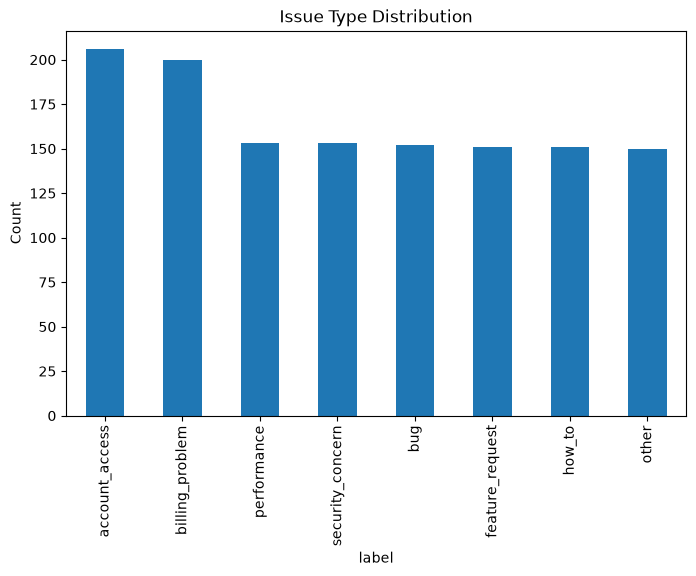

In [65]:
plt.figure(figsize=(8,5))

df["label"].value_counts().plot(kind="bar")

plt.title("Issue Type Distribution")

plt.ylabel("Count")

plt.show()

count    1316.000000
mean       98.323708
std        23.142542
min        16.000000
25%        81.000000
50%        97.000000
75%       116.000000
max       164.000000
Name: length, dtype: float64


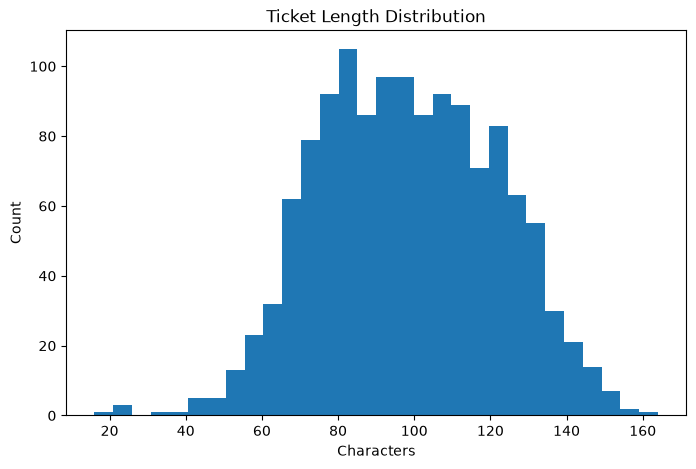

In [66]:
df["length"] = df["text"].apply(len)

print(df["length"].describe())

plt.figure(figsize=(8,5))

plt.hist(df["length"], bins=30)

plt.xlabel("Characters")

plt.ylabel("Count")

plt.title("Ticket Length Distribution")

plt.show()

In [67]:
label_encoder = LabelEncoder()

df["label_encoded"] = label_encoder.fit_transform(df["label"])

joblib.dump(
    label_encoder,
    "../models/label_encoder.pkl"
)

label_encoder.classes_

array(['account_access', 'billing_problem', 'bug', 'feature_request',
       'how_to', 'other', 'performance', 'security_concern'], dtype=object)

In [68]:
train_texts, test_texts, train_labels, test_labels = train_test_split(

    df["text"],

    df["label_encoded"],

    test_size=0.2,

    stratify=df["label_encoded"],

    random_state=42

)

print("training:",len(train_texts))

print("test:",len(test_texts))

training: 1052
test: 264


In [69]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

In [70]:
train_encodings = tokenizer(

    train_texts.tolist(),

    truncation=True,

    padding="max_length",

    max_length=48

)

test_encodings = tokenizer(

    test_texts.tolist(),

    truncation=True,

    padding="max_length",

    max_length=48

)

In [71]:
class TicketDataset(Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings

        self.labels = labels

    def __getitem__(self, idx):

        item = {

            key: torch.tensor(val[idx])

            for key, val in self.encodings.items()

        }

        item["labels"] = torch.tensor(

            self.labels.iloc[idx]

        )

        return item

    def __len__(self):

        return len(self.labels)

In [72]:
train_dataset = TicketDataset(
    train_encodings,
    train_labels.reset_index(drop=True)
)

test_dataset = TicketDataset(
    test_encodings,
    test_labels.reset_index(drop=True)
)

In [73]:
sample = train_dataset[0]

print(sample.keys())

print(sample["input_ids"].shape)

print(sample["attention_mask"].shape)

print(sample["labels"])

dict_keys(['input_ids', 'attention_mask', 'labels'])
torch.Size([48])
torch.Size([48])
tensor(3)


In [74]:
df["text_length"] = df["text"].str.len()

In [75]:
print("\nShortest Ticket:\n")
print(df.loc[df["text_length"].idxmin(), "text"])

print("\n" + "="*80)

print("\nLongest Ticket:\n")
print(df.loc[df["text_length"].idxmax(), "text"])


Shortest Ticket:

Is anyone there?


Longest Ticket:

While testing our integration, I discovered that I can access other users' data by simply changing the ID in the URL string, which seems like a major security flaw.


In [76]:
token_lengths = [
    len(tokenizer.encode(text, add_special_tokens=True))
    for text in df["text"]
]

token_lengths = pd.Series(token_lengths)

print(token_lengths.describe())

count    1316.000000
mean       23.951368
std         4.877736
min         6.000000
25%        20.000000
50%        24.000000
75%        27.000000
max        39.000000
dtype: float64


In [77]:
model = DistilBertForSequenceClassification.from_pretrained(

    "distilbert-base-uncased",

    num_labels=len(label_encoder.classes_)

)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1505.98it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [78]:
def compute_metrics(pred):

    labels = pred.label_ids

    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(

        labels,

        preds,

        average="weighted"

    )

    acc = accuracy_score(

        labels,

        preds

    )

    return {

        "accuracy": acc,

        "precision": precision,

        "recall": recall,

        "f1": f1

    }

In [79]:
training_args = TrainingArguments(
    output_dir="../results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    logging_dir="../logs",

    logging_steps=50,

    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [80]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

In [81]:
trainer.train()

C:\Users\Shristy\anaconda3\envs\ai-support\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.902803,1.404334,0.738636,0.797449,0.738636,0.728235
2,1.371535,0.951821,0.818182,0.834662,0.818182,0.813093
3,0.988358,0.829767,0.848485,0.858788,0.848485,0.846864


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.01it/s]
C:\Users\Shristy\anaconda3\envs\ai-support\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.21it/s]
C:\Users\Shristy\anaconda3\envs\ai-support\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.99it/s]


TrainOutput(global_step=198, training_loss=1.2868105955798217, metrics={'train_runtime': 439.9961, 'train_samples_per_second': 7.173, 'train_steps_per_second': 0.45, 'total_flos': 39197985371136.0, 'train_loss': 1.2868105955798217, 'epoch': 3.0})

In [82]:
predictions = trainer.predict(test_dataset)

C:\Users\Shristy\anaconda3\envs\ai-support\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [83]:
pred_labels = np.argmax(predictions.predictions, axis=1)

In [84]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_labels,
        pred_labels,
        target_names=label_encoder.classes_
    )
)

                  precision    recall  f1-score   support

  account_access       0.74      0.83      0.78        41
 billing_problem       0.86      0.90      0.88        40
             bug       1.00      0.84      0.91        31
 feature_request       0.88      0.97      0.92        30
          how_to       0.74      0.97      0.84        30
           other       0.81      0.73      0.77        30
     performance       0.97      0.94      0.95        31
security_concern       0.90      0.61      0.73        31

        accuracy                           0.85       264
       macro avg       0.86      0.85      0.85       264
    weighted avg       0.86      0.85      0.85       264



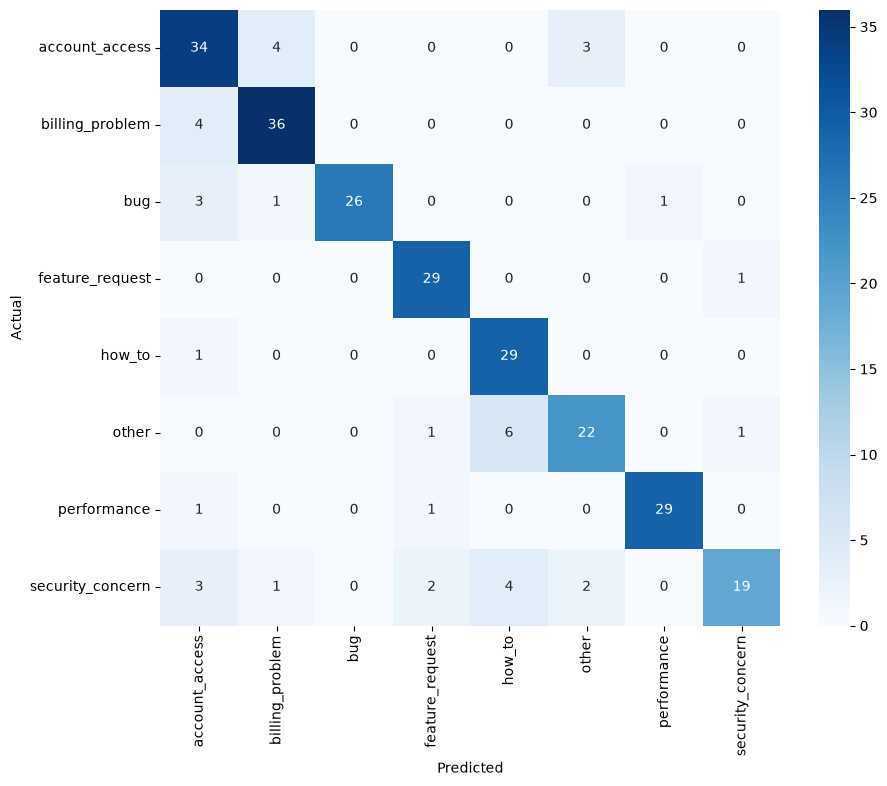

In [85]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, pred_labels)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [86]:
results = pd.DataFrame({
    "Ticket": test_texts.reset_index(drop=True),
    "Actual": label_encoder.inverse_transform(test_labels),
    "Predicted": label_encoder.inverse_transform(pred_labels)
})

errors = results[results["Actual"] != results["Predicted"]]

errors.head(20)

,Ticket,Actual,Predicted
2,Is there a limit to how many files I can have ...,other,security_concern
4,Our developers are reporting that the staging ...,performance,feature_request
8,I am concerned that your desktop app doesn't h...,security_concern,account_access
24,Is there a way to encrypt the local cache of t...,security_concern,other
25,I have the legal power of attorney for my fath...,account_access,billing_problem
40,"How do you protect against ""Session Fixation"" ...",security_concern,how_to
46,"I saw a typo on the ""About Us"" page and I thou...",other,feature_request
50,My fingerprint login works for the app but I c...,billing_problem,account_access
58,"I am unable to click the ""Accept Terms"" checkb...",bug,account_access
64,I tried to upgrade my storage through my iPhon...,billing_problem,account_access


In [87]:
model.save_pretrained("../models/issue_classifier")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.61it/s]


In [88]:
tokenizer.save_pretrained("../models/issue_classifier")

('../models/issue_classifier\\tokenizer_config.json',
 '../models/issue_classifier\\tokenizer.json')

In [89]:
import joblib

joblib.dump(
    label_encoder,
    "../models/issue_classifier/label_encoder.pkl"
)

['../models/issue_classifier/label_encoder.pkl']

In [90]:
import json

label_map = {
    i: label
    for i, label in enumerate(label_encoder.classes_)
}

with open(
    "../models/issue_classifier/label_mapping.json",
    "w"
) as f:
    json.dump(label_map, f, indent=4)

In [91]:
metrics = {
    "accuracy": 0.85,
    "macro_f1": 0.85,
    "weighted_f1": 0.85,
    "num_classes": 8,
    "model": "DistilBERT"
}

with open(
    "../models/issue_classifier/model_metrics.json",
    "w"
) as f:
    json.dump(metrics, f, indent=4)

In [92]:
import torch

model.eval()

def predict_issue(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=48
    )

    with torch.no_grad():

        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)[0]

    top3 = torch.topk(probs, k=3)

    predictions = []

    for idx, score in zip(top3.indices, top3.values):

        predictions.append({

            "label": label_encoder.inverse_transform(
                [idx.item()]
            )[0],

            "confidence": round(
                score.item()*100,
                2
            )
        })

    return predictions

In [94]:
sample = predict_issue(
    "My payment failed even though I have enough money."
)

sample

[{'label': 'billing_problem', 'confidence': 66.66},
 {'label': 'account_access', 'confidence': 9.33},
 {'label': 'security_concern', 'confidence': 7.04}]